# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Dataset

In [ ]:
df = pd.read_csv("Salary_Data.csv")

In [ ]:
X = df["YearsExperience"].values
y = df['Salary'].values

In [ ]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [ ]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

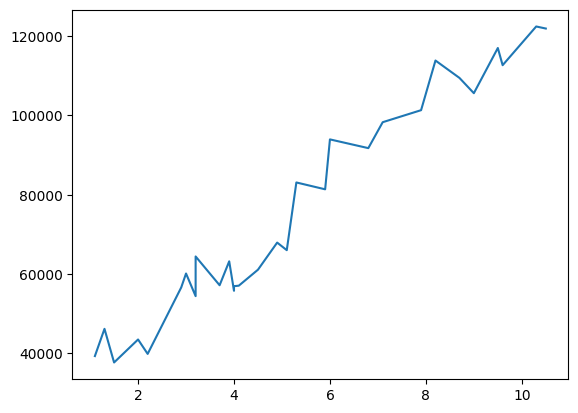

In [ ]:
plt.plot(X, y)

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
def mean(X):
  return np.sum(X)/len(X)

In [ ]:
def varience(X):
  mean_value = mean(X)
  return np.sum((X-mean_value)**2)/len(X)

In [ ]:
def norm(X):
  mean_value = mean(X)
  variance_value = varience(X)
  return (X - mean_value)/np.sqrt(variance_value)

In [ ]:
X_norm = norm(X)

In [ ]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

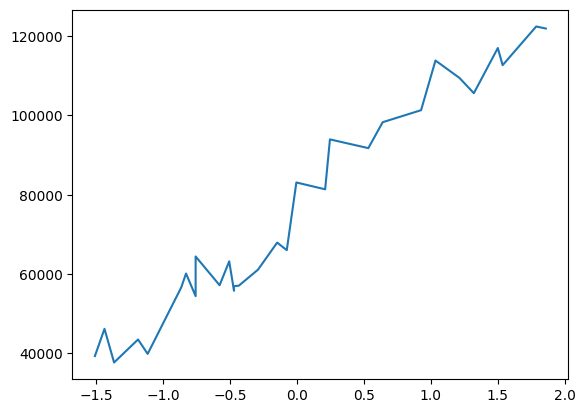

In [ ]:
plt.plot(X_norm, y)

In [ ]:
import random
class SimpleLR:
  def __init__(self, lr=0.1, max_iter=2000, threshold = 1e-6):
    self.lr = lr
    self.max_iter = max_iter
    self.threshold = threshold
    self.weight = random.uniform(-1, 1)
    self.bias = random.uniform(-1, 1)

  def predict(self, X):
    return self.weight*X + self.bias

  def fit(self, X, y):
    m = len(X)
    loss_history = []
    y_pred = self.predict(X)
    error = y - y_pred
    prev_loss = (1/(2*m))*np.sum(error**2)
    loss_history.append(prev_loss)
    for i in range(self.max_iter):
      w_grad = (1/m)*np.sum(error*X)
      b_grad = (1/m)*np.sum(error)

      self.weight   += self.lr*w_grad
      self.bias += self.lr*b_grad

      error = y - self.predict(X)
      curr_loss = (1/(2*m))*np.sum(error**2)
      if np.abs(curr_loss - prev_loss) < self.threshold:
        break
      prev_loss = curr_loss
      loss_history.append(curr_loss)
    return loss_history
  def plot(self, X, y):
    y_pred = self.predict(X)
    plt.plot(X, y)
    plt.plot(X, y_pred)

In [ ]:
model = SimpleLR()

In [ ]:
loss_history = model.fit(X_norm, y)

In [ ]:
loss_history

[np.float64(3251432580.3416657),
 np.float64(2636631130.4903655),
 np.float64(2138641956.1108127),
 np.float64(1735270724.863375),
 np.float64(1408540027.5529504),
 np.float64(1143888162.7315066),
 np.float64(929520152.2261372),
 np.float64(755882063.7167877),
 np.float64(615235212.0242147),
 np.float64(501311262.1532307),
 np.float64(409032862.7577335),
 np.float64(334287359.247381),
 np.float64(273743501.4039952),
 np.float64(224702976.55085286),
 np.float64(184980151.41980758),
 np.float64(152804663.06366077),
 np.float64(126742517.49518193),
 np.float64(105632179.58471408),
 np.float64(88532805.87723508),
 np.float64(74682313.17417704),
 np.float64(63463414.084700085),
 np.float64(54376105.82222379),
 np.float64(47015386.129617974),
 np.float64(41053203.17860728),
 np.float64(36223834.98828858),
 np.float64(32312046.75413043),
 np.float64(29143498.28446232),
 np.float64(26576974.02403116),
 np.float64(24498089.373081908),
 np.float64(22814192.80581301),
 np.float64(21450236.5863252

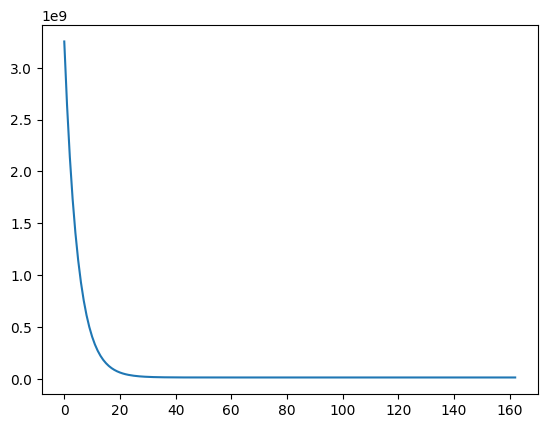

In [ ]:
plt.plot(loss_history)

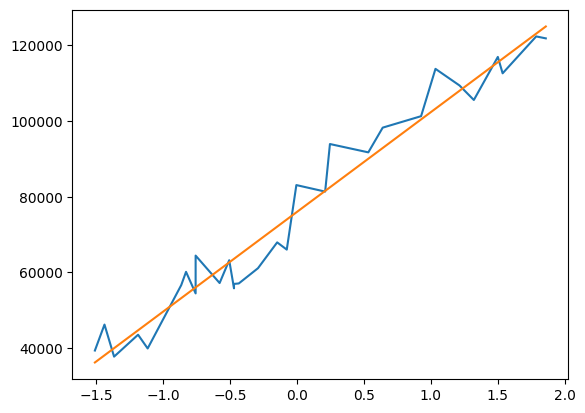

In [ ]:
model.plot(X_norm, y)